In [2]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = last 4 digits of your Drexel ID.
import numpy as np
import matplotlib.pyplot as plt

drexel_id_last4 = 3155  # replace with the last 4 digits of your Drexel ID
rng = np.random.default_rng(drexel_id_last4)

n_readings = 200
timestamps = np.sort(rng.uniform(0.0, 10.0, size=n_readings))
sensor_a = rng.normal(loc=25.0, scale=3.0, size=n_readings)
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n_readings)

# Optional: verify shapes and basic statistics
print(f"timestamps: {timestamps.shape}, sensor_a: {sensor_a.shape}, sensor_b: {sensor_b.shape}")
print(f"Sensor A mean={sensor_a.mean():.2f}, std={sensor_a.std():.2f}")
print(f"Sensor B mean={sensor_b.mean():.2f}, std={sensor_b.std():.2f}")

timestamps: (200,), sensor_a: (200,), sensor_b: (200,)
Sensor A mean=25.30, std=3.25
Sensor B mean=27.02, std=4.44


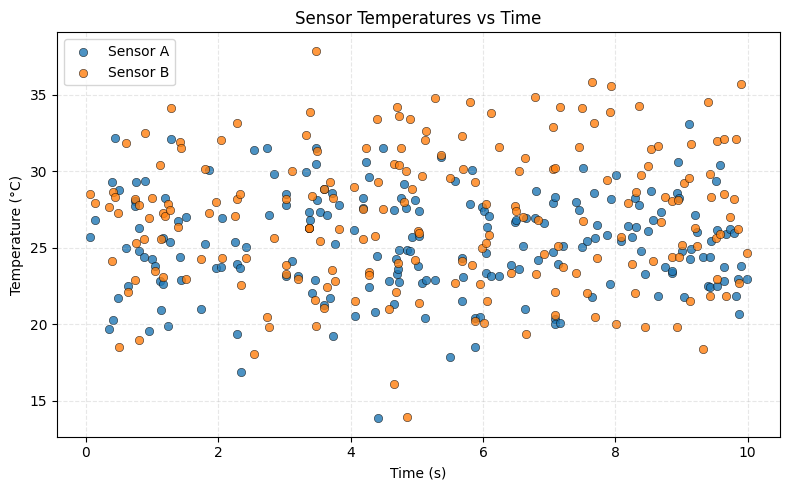

In [4]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.
plt.figure(figsize=(8, 5))
plt.scatter(timestamps, sensor_a, color='tab:blue', label='Sensor A', alpha=0.8, edgecolors='k', linewidth=0.4)
plt.scatter(timestamps, sensor_b, color='tab:orange', label='Sensor B', alpha=0.8, edgecolors='k', linewidth=0.4)
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Sensor Temperatures vs Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

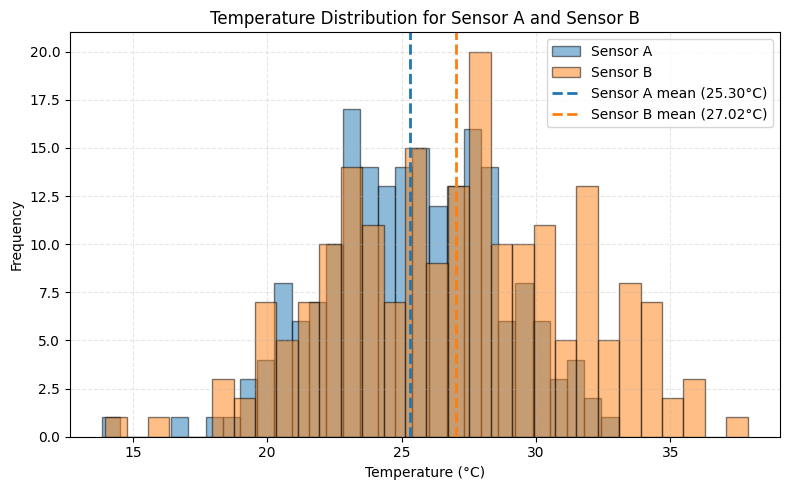

In [5]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.

plt.figure(figsize=(8, 5))
plt.hist(sensor_a, bins=30, alpha=0.5, label='Sensor A', color='tab:blue', edgecolor='black')
plt.hist(sensor_b, bins=30, alpha=0.5, label='Sensor B', color='tab:orange', edgecolor='black')

mean_a = sensor_a.mean()
mean_b = sensor_b.mean()
plt.axvline(mean_a, color='tab:blue', linestyle='--', linewidth=2, label=f'Sensor A mean ({mean_a:.2f}°C)')
plt.axvline(mean_b, color='tab:orange', linestyle='--', linewidth=2, label=f'Sensor B mean ({mean_b:.2f}°C)')

plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Temperature Distribution for Sensor A and Sensor B')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_69968/4195070164.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, patch_artist=True,


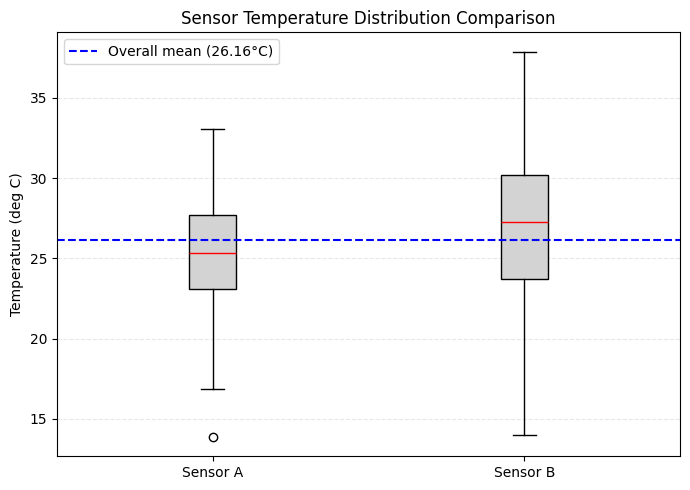

In [6]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.

plt.figure(figsize=(7, 5))
data = [sensor_a, sensor_b]
labels = ['Sensor A', 'Sensor B']
plt.boxplot(data, labels=labels, patch_artist=True,
            boxprops=dict(facecolor='lightgray', edgecolor='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'))

overall_mean = np.concatenate(data).mean()
plt.axhline(overall_mean, color='blue', linestyle='--', linewidth=1.5,
            label=f'Overall mean ({overall_mean:.2f}°C)')

plt.ylabel('Temperature (deg C)')
plt.title('Sensor Temperature Distribution Comparison')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()